
# Hospital Readmission Risk Analysis for Diabetic Patients
## Exploratory Analysis

---

<br>
This notebook serves to explore the data from the UCI dataset available at:
<a href="https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008" target="_blank">https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008</a>

According to the authors of the dataset:<br>
"The dataset represents ten years (1999-2008) of clinical care at 130 US hospitals and integrated delivery networks. Each row concerns hospital records of patients diagnosed with diabetes, who underwent laboratory, medications, and stayed up to 14 days. The goal is to determine the early readmission of the patient within 30 days of discharge. The problem is important for the following reasons. Despite high-quality evidence showing improved clinical outcomes for diabetic patients who receive various preventive and therapeutic interventions, many patients do not receive them. This can be partially attributed to arbitrary diabetes management in hospital environments, which fail to attend to glycemic control. Failure to provide proper diabetes care not only increases the managing costs for the hospitals (as the patients are readmitted) but also impacts the morbidity and mortality of the patients, who may face complications associated with diabetes."
<br><br>
<div align="center">
    <b>Dataset Characteristics</b>:<br>Multivariate<br><br>
    <b>Subject Area</b>:<br>Health and Medicine<br><br>
    <b>Associated Tasks</b>:<br>Classification, Clustering<br><br>
    <b>Feature Type</b>:<br>Categorical, Integer<br><br>
    <b># Instances</b>:<br>101766<br><br>
    <b># Features</b>:<br>47
</div>
<br>

---
---

#### Imports

In [210]:
import pandas as pd
import seaborn as sns
import numpy as np
from matplotlib import pyplot as plt
from scipy.stats import chi2_contingency
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, TargetEncoder
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import cross_val_score

#### Seaborn Config

In [211]:
sns.set_theme(style="darkgrid", palette="viridis")
plt.rcParams["figure.dpi"] = 150
plt.rcParams["savefig.dpi"] = 150
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["font.size"] = 12
pd.set_option('display.max_colwidth', None)

#### Load data set 

In [212]:
# Load the raw diabetes dataset
diabetes_df = pd.read_csv("../data/raw/diabetic_data.csv")

# Replace NaN values with the intended 'none' values
diabetes_df.replace(np.nan, 'none', inplace=True)

# Replace missing value placeholders ("?") with np.nan for standard NaN representation
diabetes_df.replace("?", np.nan, inplace=True)

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,443847548,100162476,AfricanAmerican,Male,[70-80),NaN,1,3,7,3,...,No,Down,No,No,No,No,No,Ch,Yes,>30
101762,443847782,74694222,AfricanAmerican,Female,[80-90),NaN,1,4,5,5,...,No,Steady,No,No,No,No,No,No,Yes,NO
101763,443854148,41088789,Caucasian,Male,[70-80),NaN,1,1,7,1,...,No,Down,No,No,No,No,No,Ch,Yes,NO
101764,443857166,31693671,Caucasian,Female,[80-90),NaN,2,3,7,10,...,No,Up,No,No,No,No,No,Ch,Yes,NO


#### Handling Duplicates

In [213]:
# Display the number of encounters per patient to check for duplicate patient_nbr entries
patient_nbr = diabetes_df['patient_nbr']
patient_nbr.value_counts()

patient_nbr
88785891     40
43140906     28
1660293      23
23199021     23
88227540     23
             ..
183087545     1
188574944     1
140199494     1
120975314     1
175429310     1
Name: count, Length: 71518, dtype: int64

There are 71518 unique patients in the dataset with the remaining records being associated with repeated encounters with those same patients. An argument could be made for both retaining the records and deduplicating them. For the former, there is potentially a lot of signal in each record and without a complex deduplication strategy, we risk removing the more informative encouter records. Additionally, the model built upon this data would be used on patients with similar repeated encounters, so retaining the data reflects more closely the data that the model would see in real world application. For the latter, it is the statistically sound to always remove related records since i.i.d is assumed at several steps in processing the data and building the model. 

Here, we will follow the lead of academic treatments of this dataset and remove duplicated while retaining the record with the highest `time_in_hospital`. 

In [214]:
# Sort by 'time_in_hospital' in descending order so that, for each patient,
# the encounter with the longest hospital stay comes first. Then drop duplicates
# to retain only one record per patient_nbr, keeping the longest stay.
diabetes_df = (
    diabetes_df
    .sort_values('time_in_hospital', ascending=False)
    .drop_duplicates(subset='patient_nbr', keep='first')
)

# Ensure that every patient number is unique in the dataframe after deduplication
assert diabetes_df['patient_nbr'].nunique() == len(diabetes_df)

#### Feature Descriptions 

In [215]:
features_df = pd.read_csv("../data/raw/diabetic_data_variables.csv", index_col=0)
target_series = features_df.iloc[-1]
features_df.drop(columns=["units", "demographic", "role"], inplace=True)
features_df.drop([0,1], inplace=True)
features_df.reset_index(drop=True, inplace=True)
display(features_df)

,name,type,description,missing_values
0,race,Categorical,"Values: Caucasian, Asian, African American, Hispanic, and other",yes
1,gender,Categorical,"Values: male, female, and unknown/invalid",no
2,age,Categorical,"Grouped in 10-year intervals: [0, 10), [10, 20),..., [90, 100)",no
3,weight,Categorical,Weight in pounds.,yes
4,admission_type_id,Categorical,"Integer identifier corresponding to 9 distinct values, for example, emergency, urgent, elective, newborn, and not available",no
5,discharge_disposition_id,Categorical,"Integer identifier corresponding to 29 distinct values, for example, discharged to home, expired, and not available",no
6,admission_source_id,Categorical,"Integer identifier corresponding to 21 distinct values, for example, physician referral, emergency room, and transfer from a hospital",no
7,time_in_hospital,Integer,Integer number of days between admission and discharge,no
8,payer_code,Categorical,"Integer identifier corresponding to 23 distinct values, for example, Blue Cross/Blue Shield, Medicare, and self-pay",yes
9,medical_specialty,Categorical,"Integer identifier of a specialty of the admitting physician, corresponding to 84 distinct values, for example, cardiology, internal medicine, family/general practice, and surgeon",yes


In [216]:
# Separate numerical and categorical features
numerical_cols = features_df[features_df["type"]=="Integer"]["name"].to_list()
categorical_cols = features_df[features_df["type"]=="Categorical"]["name"].to_list()[:-1]

print(f"Diabetes dataset has {len(numerical_cols)} numerical and {len(categorical_cols)} categorical features and {len(diabetes_df)} records")

Diabetes dataset has 8 numerical and 39 categorical features and 71518 records


### Handling Missing Data

#### Checking for Features with Missing Values

In [217]:
# Extract the names of the features with missing values
missing_fearures_names = features_df[features_df["missing_values"] == "yes"]
missing_data_df = diabetes_df[missing_fearures_names["name"]]

missing_data_df.info()

<class 'pandas.DataFrame'>
Index: 71518 entries, 28819 to 0
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   race               69601 non-null  str  
 1   weight             2860 non-null   str  
 2   payer_code         40977 non-null  str  
 3   medical_specialty  37004 non-null  str  
 4   diag_1             71506 non-null  str  
 5   diag_2             71232 non-null  str  
 6   diag_3             70370 non-null  str  
dtypes: str(7)
memory usage: 4.4 MB


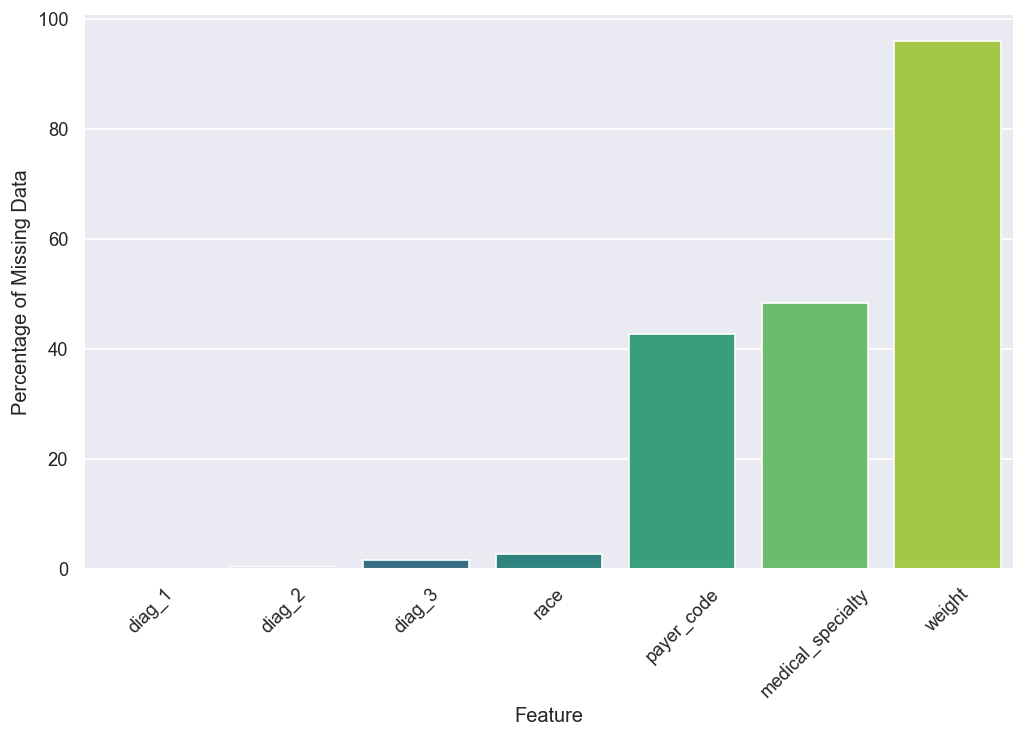

,Missingness (%)
diag_1,0.016779
diag_2,0.399899
diag_3,1.605190
race,2.680444
payer_code,42.703935
medical_specialty,48.259180
weight,96.001007


In [218]:
# Calculate the percentage of missing values per feature and display as a sorted barplot
missing_percentages = 100 * np.sum(missing_data_df.isna(), axis=0) / missing_data_df.shape[0]
missing_percentages = missing_percentages.sort_values()

# Plot the missingness per feature
plt.figure(figsize=(10, 6), dpi=120)
ax = sns.barplot(x=missing_percentages.index, y=missing_percentages.values, hue=missing_percentages.index, palette='viridis')
plt.ylabel("Percentage of Missing Data")
plt.xlabel("Feature")
plt.xticks(rotation=45)
plt.show()

# Display the missingness percentages in a table
display(pd.DataFrame(missing_percentages, columns=["Missingness (%)"]))

#### Per Class Missingness

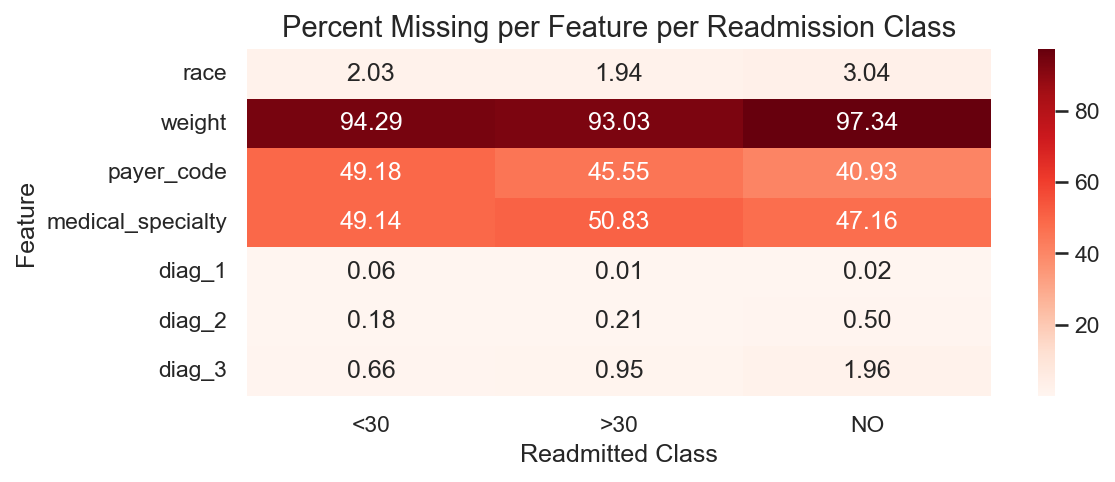

In [219]:
# Check if missingness is class-dependent — run a missingness heatmap or crosstab per class.
# Generate a crosstab of missingness per class ("readmitted")
missingness_by_class = pd.DataFrame()

for col in missing_fearures_names["name"]:
    # Get True/False mask for missing values in the feature
    mask = diabetes_df[col].isna()
    # Crosstab of missing (True/False) by readmitted class
    crosstab = pd.crosstab(mask, diabetes_df["readmitted"], normalize='columns') * 100
    crosstab.index = ['Not Missing', 'Missing'] if crosstab.shape[0] == 2 else ['Not Missing']
    crosstab["feature"] = col
    missingness_by_class = pd.concat([missingness_by_class, crosstab.reset_index()], ignore_index=True)

# Show as heatmap (features x readmitted class, values: percent missing)
pivot = missingness_by_class[missingness_by_class["index"] == "Missing"].set_index('feature').drop("index", axis=1)
plt.figure(figsize=(8, 3))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="Reds")
plt.title("Percent Missing per Feature per Readmission Class")
plt.ylabel("Feature")
plt.xlabel("Readmitted Class")
plt.show()

Missingness is very similarly distributed among classes, which is an adequate reason to believe this is a case of MAR. No per class missingness model or compensation required.

#### Handling Missing Values

The bar plot shows race, diag_1, diag_2, and diag_3 as having very few null values. Therefore, we will opt to simply delete the rows with missing values for these features.

In [220]:
# Find rows with missing values for ["race", "diag_1", "diag_2", "diag_3"] and drop them
nan_rows = np.any(missing_data_df[["race", "diag_1", "diag_2", "diag_3"]].isna(), axis = 1)
missing_data_df = missing_data_df[~nan_rows]

Weight feature has a ~97% missingness rate and will be dropped completely.

In [221]:
# Drop the `weight` column
missing_data_df = missing_data_df.drop(labels = ["weight"], axis = 1)

# Update missingness rates
missing_percentages = 100*np.sum(missing_data_df.isna(), axis=0)/missing_data_df.shape[0]
missing_percentages = missing_percentages.sort_values()
display(pd.DataFrame(missing_percentages, columns = ["Missingness (%)"]))

,Missingness (%)
race,0.000000
diag_1,0.000000
diag_2,0.000000
diag_3,0.000000
payer_code,42.908470
medical_specialty,48.475953


We are left with `payer_code` and `medical_specialty` with 39% and 49% missingness respectively. Before deciding what to do with these features, we take a look at their description to decide if any domain knowledge can be leveraged to assess their usefulness. 

In [222]:
features_df[features_df["name"].isin(["payer_code", "medical_specialty"])][["name", "description"]]

,name,description
8,payer_code,"Integer identifier corresponding to 23 distinct values, for example, Blue Cross/Blue Shield, Medicare, and self-pay"
9,medical_specialty,"Integer identifier of a specialty of the admitting physician, corresponding to 84 distinct values, for example, cardiology, internal medicine, family/general practice, and surgeon"


Since `payer_code` simply tells us the origin of payment (insurance vs self_pay), it is easy to assume it has little value in predicting readmission. We will drop it completely. As for `medical_specialty`, there are a few considerations. From a domain knowledge perspective, knowing what department admitted the patient might have meaningful information. But, it is worth noting that with 84 distinct values, we would risk an explosion of dimensionality if one hot encoding is used for preprocessing of categorical features later. Grouping based encoding or embeddings could minimize this high cardinality but are more complex and require expertise of the medical field. A good place to start instead is to assess the associaltion between this feature and the target. If usefulness is established, more efficient encodings will be considered. Otherwise the feature will be completely dropped. 

In [223]:
# function to calculate Cramier's V between two categorical columns
def cramers_v(x, y):
    # Drop rows where either variable is missing
    mask = x.notna() & y.notna()
    x, y = x[mask], y[mask]

    contingency_table = pd.crosstab(x, y)
    chi2, _, _, _ = chi2_contingency(contingency_table)
    n = contingency_table.sum().sum()
    k = min(contingency_table.shape) - 1
    return np.sqrt(chi2 / (n * k))

print("Cramér's V (medical_specialty vs readmitted):", cramers_v(diabetes_df['medical_specialty'], diabetes_df['readmitted']))
print("Cramér's V (payer_code vs readmitted):", cramers_v(diabetes_df['payer_code'], diabetes_df['readmitted']))

Cramér's V (medical_specialty vs readmitted): 0.09258835347025854
Cramér's V (payer_code vs readmitted): 0.06205694213531705


Based on the above Cramér's V results, both `medical_specialty` (Cramér's V ≈ 0.11) and `payer_code` (Cramér's V ≈ 0.06) show low association with the target variable. Combined with their high missingness rates (49% and 39% respectively), both features will be dropped from further analysis.

In [224]:
# Drop `medical_specialty` and `payer_code` columns
missing_data_df = missing_data_df.drop(labels = ["medical_specialty", "payer_code"], axis = 1)

# Combine the fixed missingness dataframe with the non-missing features to reconstruct the cleaned data
# Select features that had no missing values
none_missing_features = features_df[features_df["missing_values"] == "no"]["name"]
# Copy those columns from the original dataframe
non_missing_df = diabetes_df[none_missing_features].copy()[~nan_rows]
# Concatenate non-missing and now-complete missingness columns along columns axis
missingness_fixed_diabetes_df = pd.concat([missing_data_df, non_missing_df], axis=1)
missingness_fixed_diabetes_df.head()

,race,diag_1,diag_2,diag_3,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
28819,Caucasian,250.8,707,682,Male,[60-70),2,1,1,14,...,No,Steady,No,No,No,No,No,Ch,Yes,>30
19368,Caucasian,428,250.02,599,Female,[80-90),1,3,7,14,...,No,Down,No,No,No,No,No,Ch,Yes,NO
74178,AfricanAmerican,V57,438,438,Male,[80-90),2,6,1,14,...,No,No,No,No,No,No,No,No,No,NO
38988,Caucasian,250.13,263,V15,Female,[20-30),1,3,5,14,...,No,Down,No,No,No,No,No,Ch,Yes,NO
24998,Caucasian,428,511,788,Male,[80-90),6,22,17,14,...,No,Down,No,No,No,No,No,Ch,Yes,>30


In [225]:
# Drop "weight", "medical_specialty", and "payer_code" from features_df and reset index
features_df = features_df[~features_df["name"].isin(["weight", "medical_specialty", "payer_code"])]
features_df = features_df.reset_index(drop=True)
features_df

,name,type,description,missing_values
0,race,Categorical,"Values: Caucasian, Asian, African American, Hispanic, and other",yes
1,gender,Categorical,"Values: male, female, and unknown/invalid",no
2,age,Categorical,"Grouped in 10-year intervals: [0, 10), [10, 20),..., [90, 100)",no
3,admission_type_id,Categorical,"Integer identifier corresponding to 9 distinct values, for example, emergency, urgent, elective, newborn, and not available",no
4,discharge_disposition_id,Categorical,"Integer identifier corresponding to 29 distinct values, for example, discharged to home, expired, and not available",no
5,admission_source_id,Categorical,"Integer identifier corresponding to 21 distinct values, for example, physician referral, emergency room, and transfer from a hospital",no
6,time_in_hospital,Integer,Integer number of days between admission and discharge,no
7,num_lab_procedures,Integer,Number of lab tests performed during the encounter,no
8,num_procedures,Integer,Number of procedures (other than lab tests) performed during the encounter,no
9,num_medications,Integer,Number of distinct generic names administered during the encounter,no


### Exploring Numerical Features

#### Visualization

In [226]:
numerical_features_only_df = missingness_fixed_diabetes_df[features_df[features_df["type"]=="Integer"]["name"].values.tolist()]
numerical_features_only_df["readmitted"]= missingness_fixed_diabetes_df["readmitted"]
numerical_features_only_df.describe()

,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,68469.000000,68469.000000,68469.000000,68469.000000,68469.000000,68469.000000,68469.000000,68469.000000
mean,4.799208,44.252932,1.502052,16.525201,0.312725,0.128146,0.347237,7.448656
std,3.190665,20.015248,1.780832,8.594928,1.134123,0.650942,0.846464,1.861612
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,3.000000
25%,2.000000,32.000000,0.000000,11.000000,0.000000,0.000000,0.000000,6.000000
50%,4.000000,45.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,7.000000,58.000000,2.000000,21.000000,0.000000,0.000000,0.000000,9.000000
max,14.000000,132.000000,6.000000,81.000000,40.000000,63.000000,19.000000,16.000000


##### Boxplots

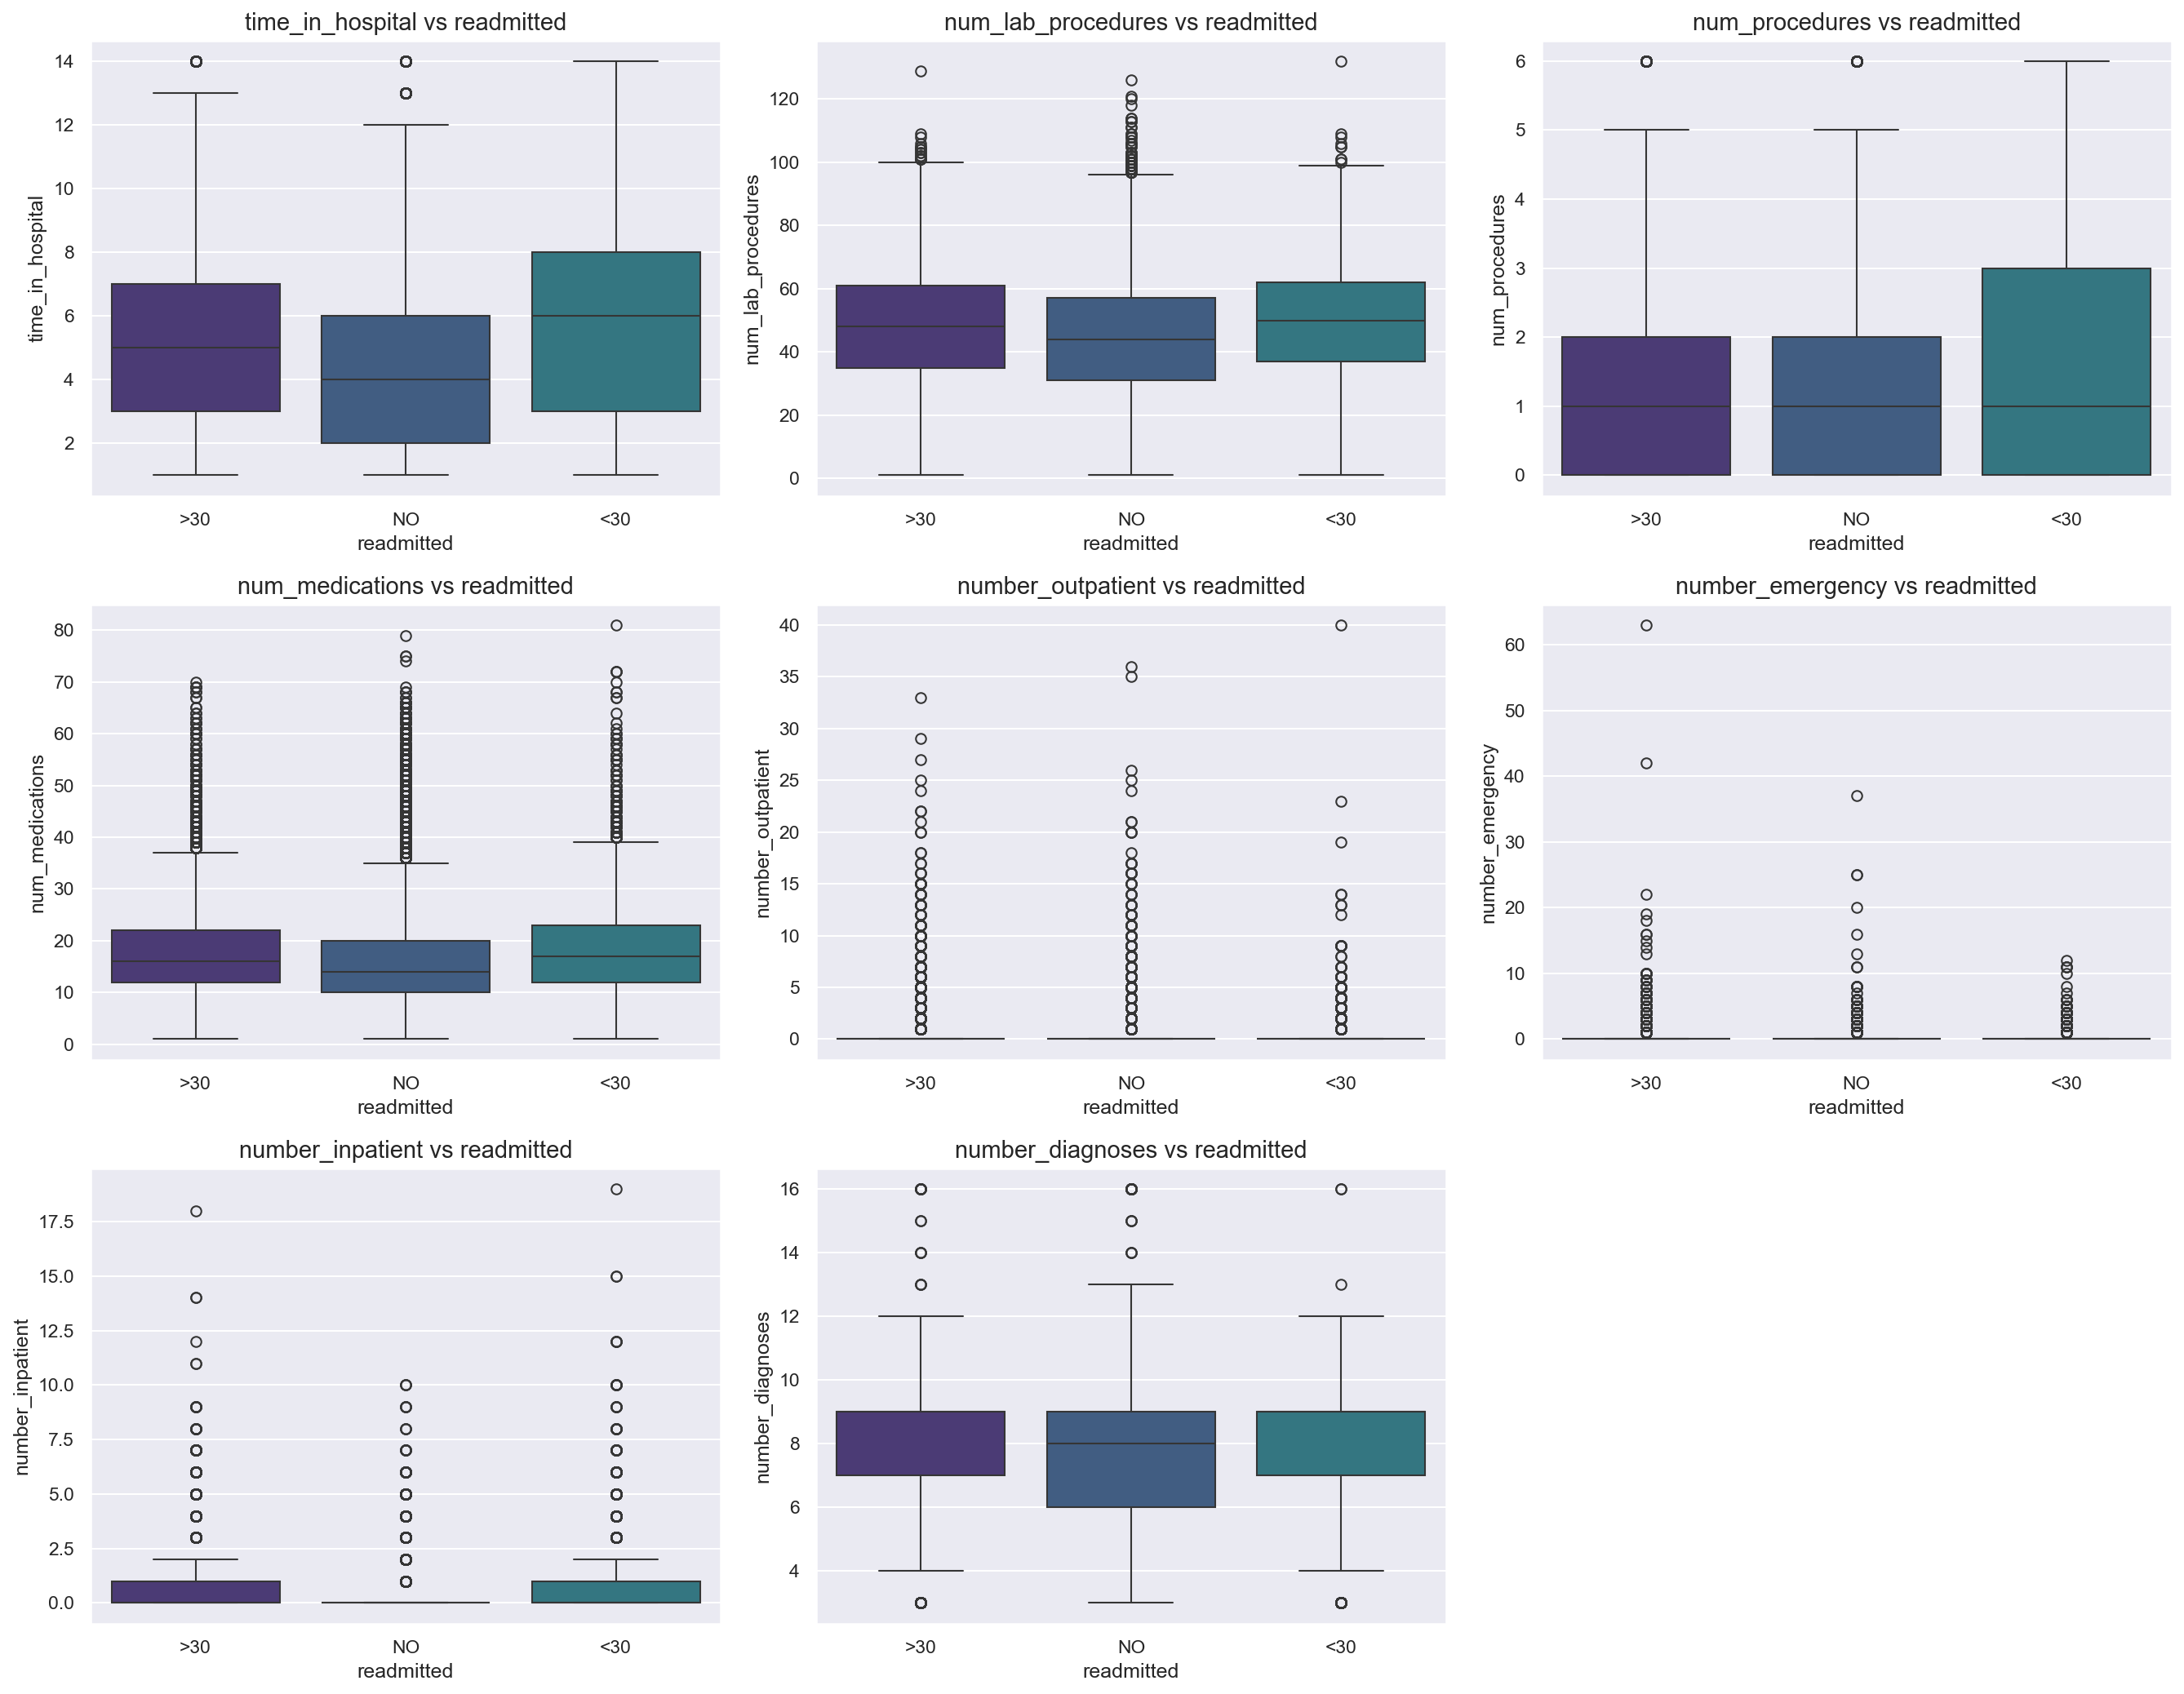

In [227]:
# Set up a 3x3 grid of subplots for boxplots
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

# Plot a boxplot for each numerical feature grouped by 'readmitted'
for i, feature in enumerate(numerical_cols):
    ax = axes[i]
    sns.boxplot(data=numerical_features_only_df, x="readmitted", y=feature, ax=ax, hue="readmitted")
    ax.set_title(f"{feature} vs readmitted")

# Remove any unused subplots if less than 9 features
for j in range(len(numerical_cols), 9):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

##### Histograms

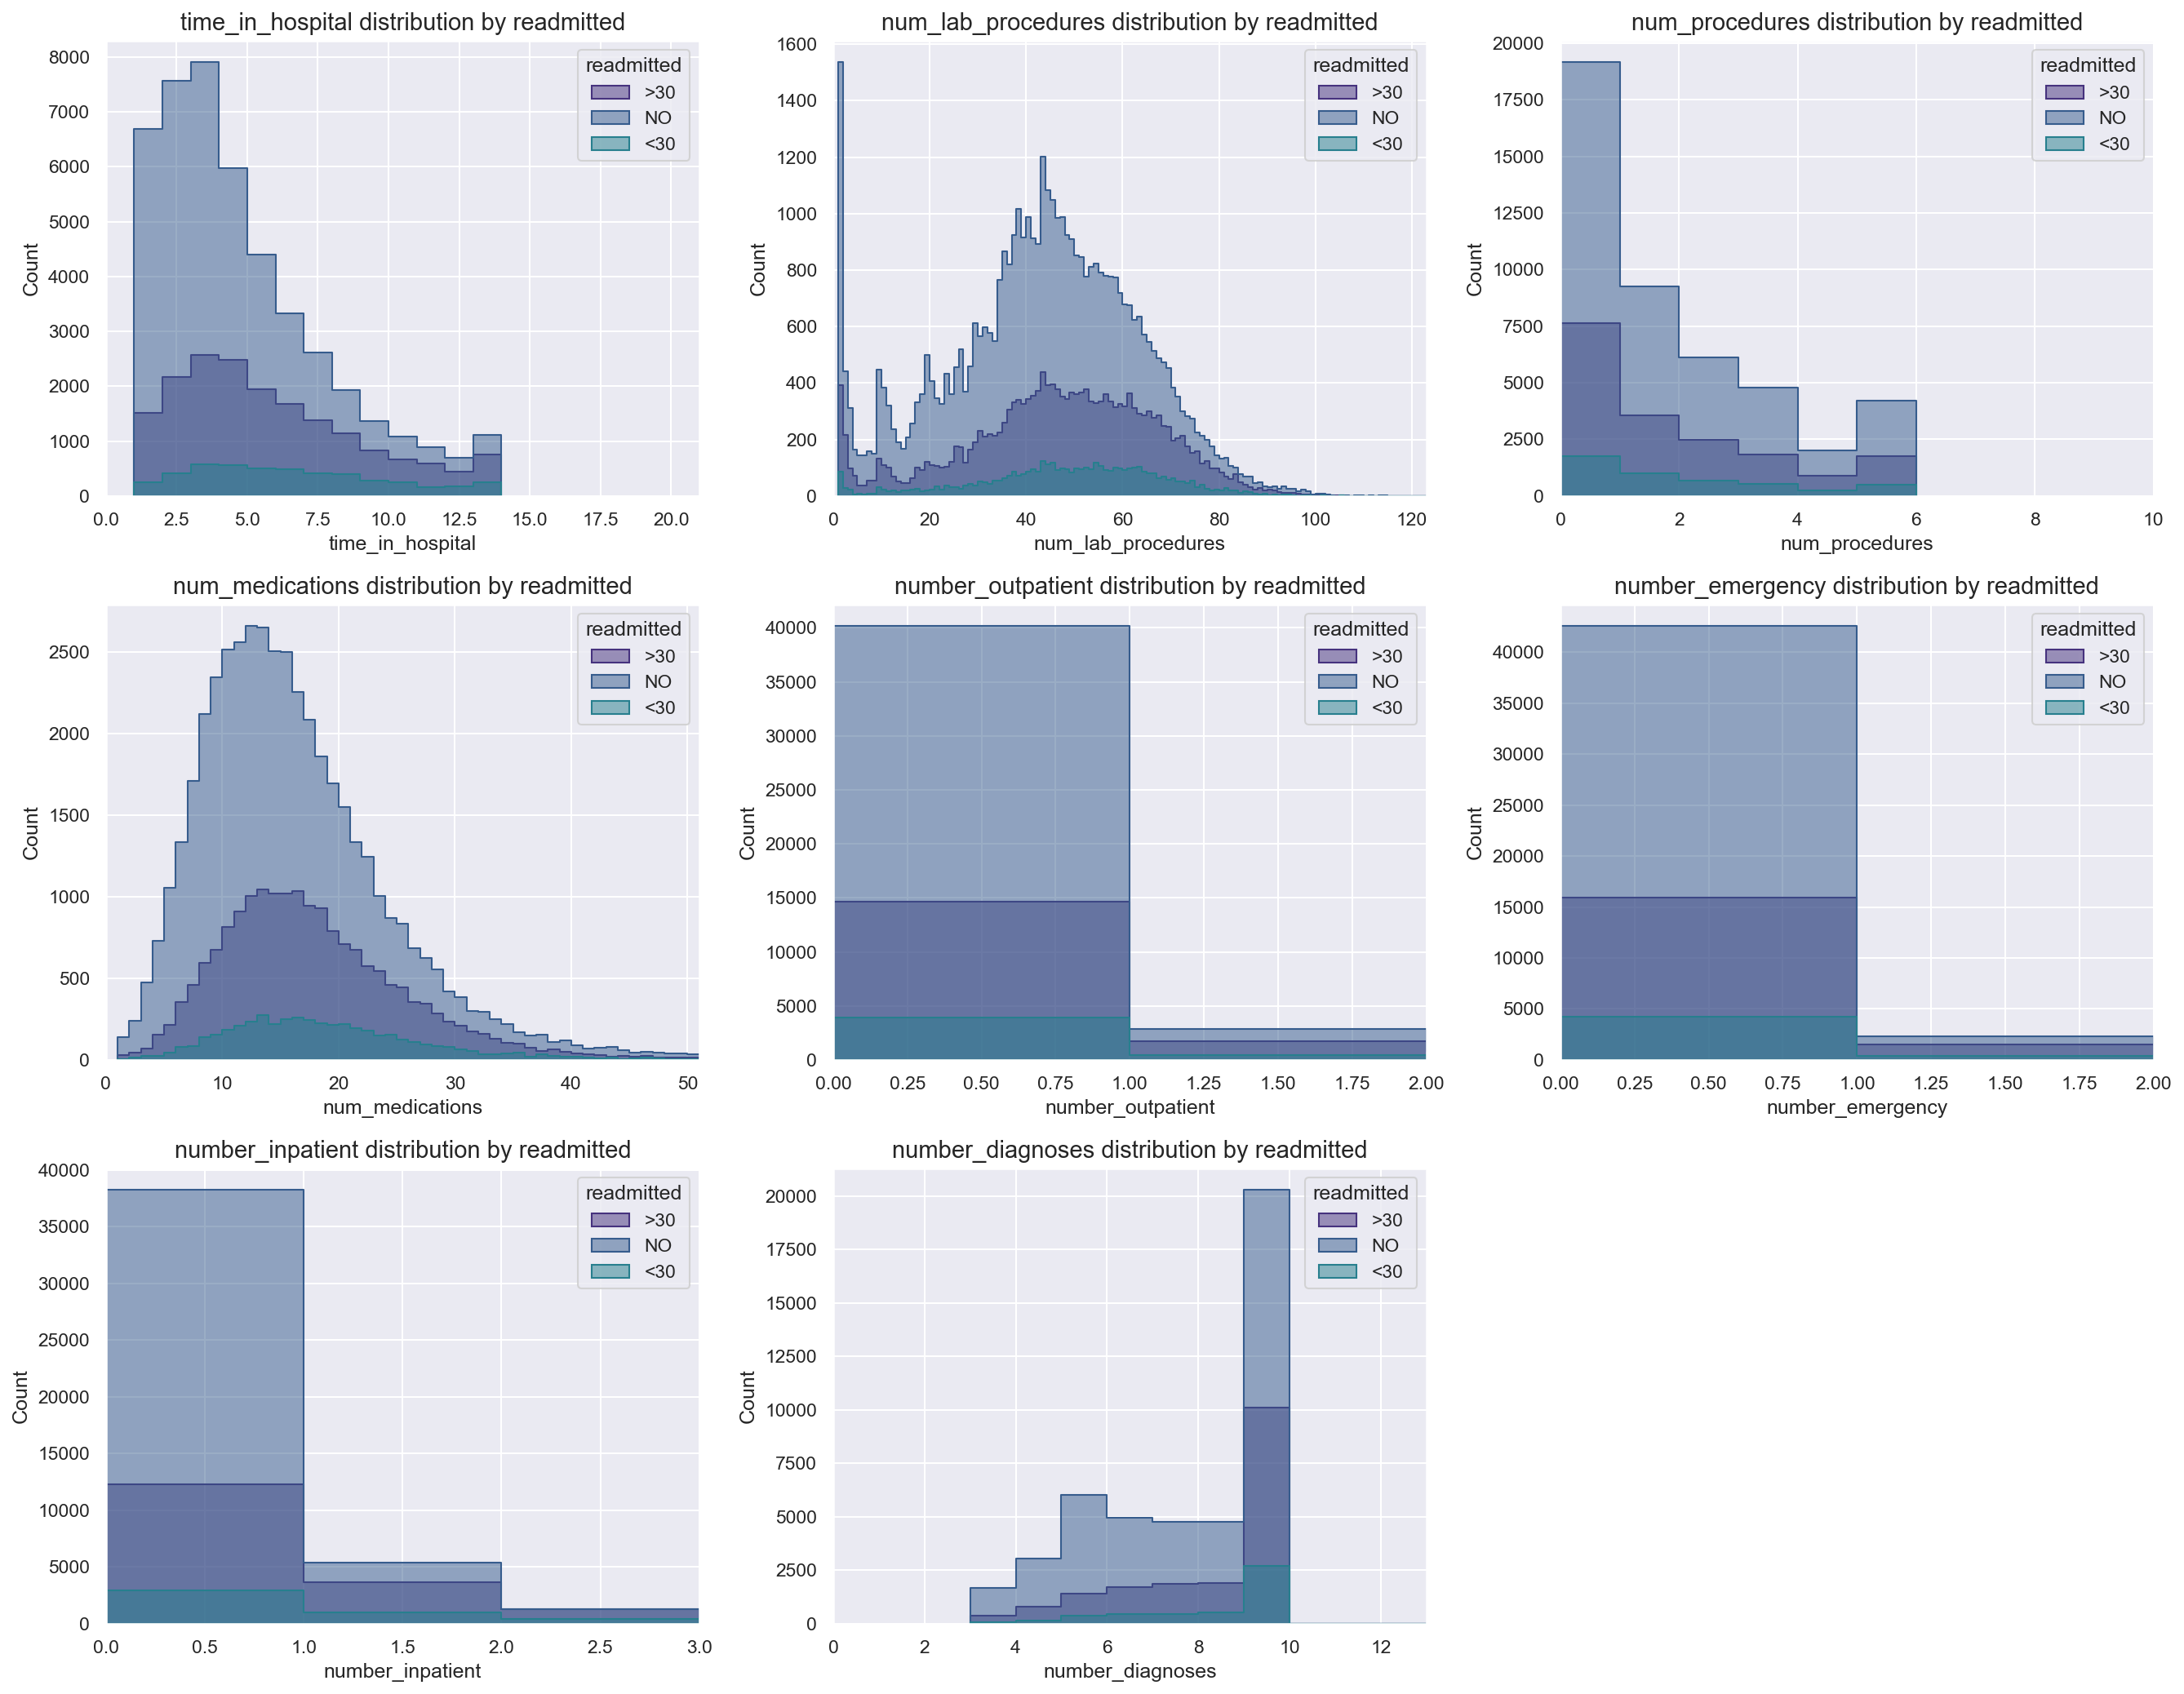

In [228]:
# Plot a grid of histograms for each numerical feature, showing distribution per `readmitted` target
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for i, feature in enumerate(numerical_cols):
    ax = axes[i]
    for target_value in numerical_features_only_df["readmitted"].unique():
        subset = numerical_features_only_df[numerical_features_only_df["readmitted"] == target_value]
        sns.histplot(subset[feature], label=str(target_value), ax=ax, element="step", alpha=0.5, binwidth=1)
    ax.set_title(f"{feature} distribution by readmitted")
    ax.legend(title="readmitted")
    iqr = subset[feature].quantile(0.75) - subset[feature].quantile(0.25)
    ax.set_xlim([0,int(max(subset[feature].mean()+3*iqr,2))])


# Remove any unused subplots if less than 9 features
for j in range(len(numerical_cols), 9):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

As can be seen for the boxplots and the histograms per target class, most of the numerical features have very similar distrutions for the different targets, which renders their discriminative power low. The only exception is `number_inpatient` where we can see a noticeable distribution for each target. Additionally, features like `num_medication`, `num_lab_procedures`, and others have a higher number of outliers than we would typcically want. To address that, the datapoints outside of the [Q1-1.5xIQR, Q3+1.5xIQR] would be dropped. In this case we will opt to retain them in case other features of the datapoints have more discriminative power. This is especially needed since so far very few features have shown to represent adequate signal. 

#### ETA Squared 

In [229]:
# Computes the eta squared statistic
def eta_squared(feature, target):
    # Create groups by unique values in the target, removing missing values in each group
    groups = [feature[target == cls].dropna() for cls in target.unique()]
    # Calculate the mean of the entire feature (excluding NaNs)
    grand_mean = feature.dropna().mean()
    # Between-group sum of squares
    ss_between = sum(len(g) * (g.mean() - grand_mean)**2 for g in groups)
    # Total sum of squares
    ss_total = sum((feature.dropna() - grand_mean)**2)
    # Eta squared: proportion of variance explained by the grouping
    return float(ss_between / ss_total)

etas = {}
for feature in numerical_cols:
    etas[feature] = eta_squared(numerical_features_only_df[feature], numerical_features_only_df['readmitted'])

etas = pd.Series(data=etas).sort_values()
etas = pd.DataFrame(data=etas, index=etas.index, columns=["eta_squared"])
etas

,eta_squared
num_procedures,0.000448
number_outpatient,0.005851
number_emergency,0.006975
num_medications,0.010798
num_lab_procedures,0.010937
number_diagnoses,0.016182
time_in_hospital,0.030721
number_inpatient,0.045387


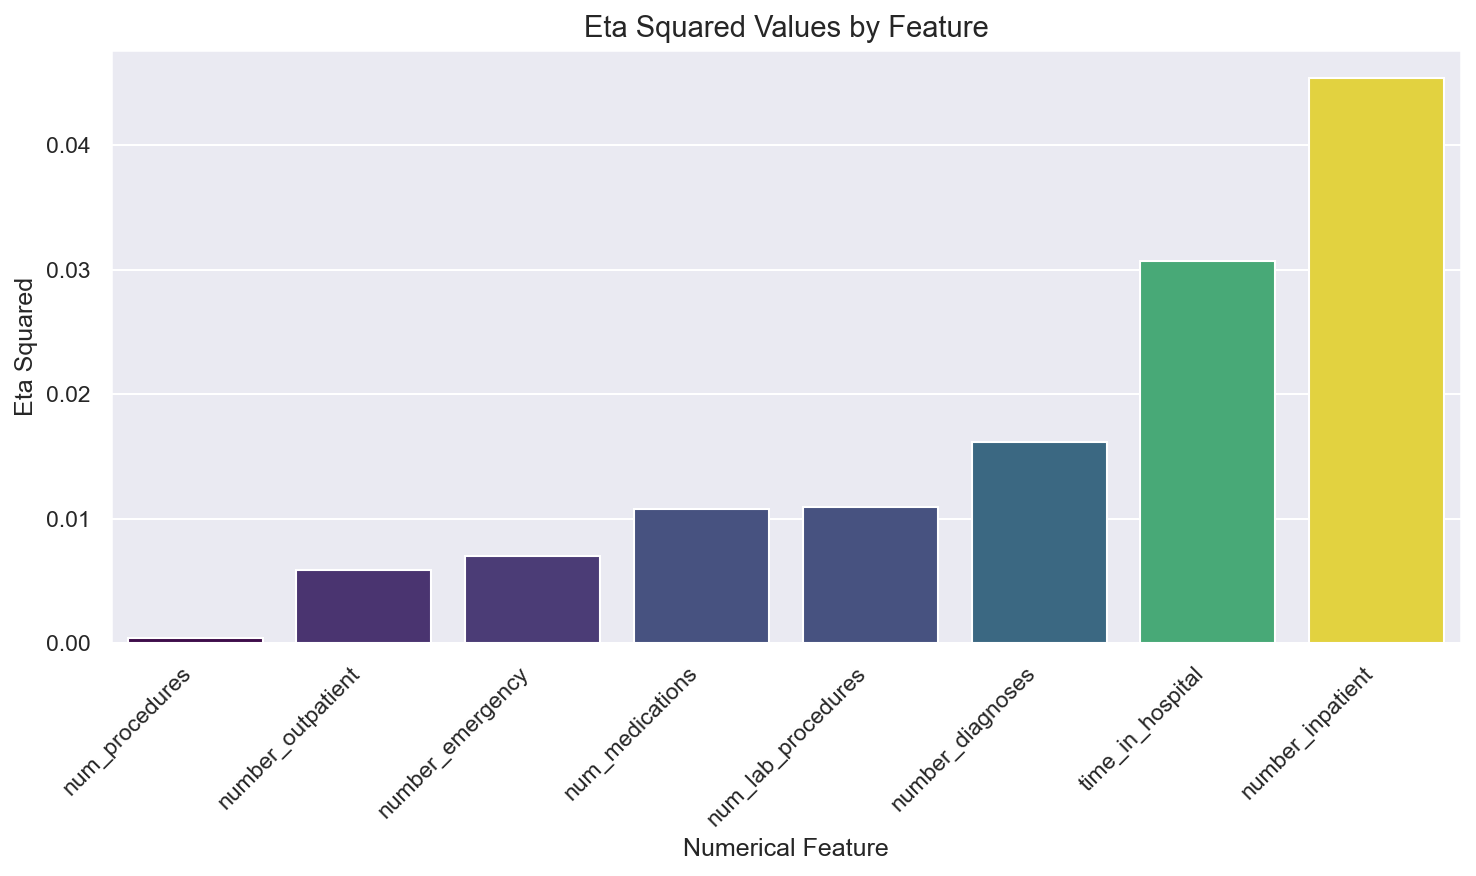

In [230]:
plt.figure(figsize=(10, 6))
sns.barplot(x=etas.index, y=etas["eta_squared"], hue=etas["eta_squared"], palette="viridis")
plt.title("Eta Squared Values by Feature")
plt.ylabel("Eta Squared")
plt.xlabel("Numerical Feature")
plt.xticks(rotation=45, ha='right')
plt.legend([],[], frameon=False)  # Remove legend
plt.tight_layout()
plt.show()

The Eta squared score is between 0 and 1 and reveals the association between the numerical feature and the categorical target we have in `readmitted`. The sorted scores above underscore what the boxplots revealed in terms of the numerical features of this data set having low association with the target. Notably, the features `number_inpatient` and `number_diagnoses` have the highest scores. We will keep that in mind if further feature selection is performed.

### Categorical Features 

#### Visualization

In [231]:
categorical_cols = [cat_col for cat_col in categorical_cols if cat_col not in ['weight', 'payer_code', 'medical_specialty']]
categorical_features_only_df = missingness_fixed_diabetes_df[categorical_cols]
categorical_features_only_df['readmitted'] = missingness_fixed_diabetes_df['readmitted']
categorical_features_only_df.head()

,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,diag_1,diag_2,diag_3,max_glu_serum,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
28819,Caucasian,Male,[60-70),2,1,1,250.8,707,682,none,...,No,Steady,No,No,No,No,No,Ch,Yes,>30
19368,Caucasian,Female,[80-90),1,3,7,428,250.02,599,none,...,No,Down,No,No,No,No,No,Ch,Yes,NO
74178,AfricanAmerican,Male,[80-90),2,6,1,V57,438,438,none,...,No,No,No,No,No,No,No,No,No,NO
38988,Caucasian,Female,[20-30),1,3,5,250.13,263,V15,none,...,No,Down,No,No,No,No,No,Ch,Yes,NO
24998,Caucasian,Male,[80-90),6,22,17,428,511,788,none,...,No,Down,No,No,No,No,No,Ch,Yes,>30


In [232]:
categorical_cardinality_sr = categorical_features_only_df.nunique()
pd.DataFrame(categorical_cardinality_sr, columns=["Unique Values"]).sort_values(by="Unique Values")

,Unique Values
citoglipton,1
metformin-rosiglitazone,1
glimepiride-pioglitazone,1
examide,1
acetohexamide,2
troglitazone,2
tolazamide,2
diabetesMed,2
tolbutamide,2
glipizide-metformin,2


Features like `diag_1` and `diag_2` have too many unique values to offer much insight in a countplot. Additionally, features `citoglipton` and `examide` have only 1 possible value so they can be completely dropped.

In [233]:
low_card_categorical_cols = [cat_col for cat_col in categorical_cols if 1 < categorical_cardinality_sr[cat_col] <=10]
low_card_categorical_features_only_df = categorical_features_only_df[low_card_categorical_cols]
low_card_categorical_features_only_df['readmitted'] = categorical_features_only_df['readmitted']

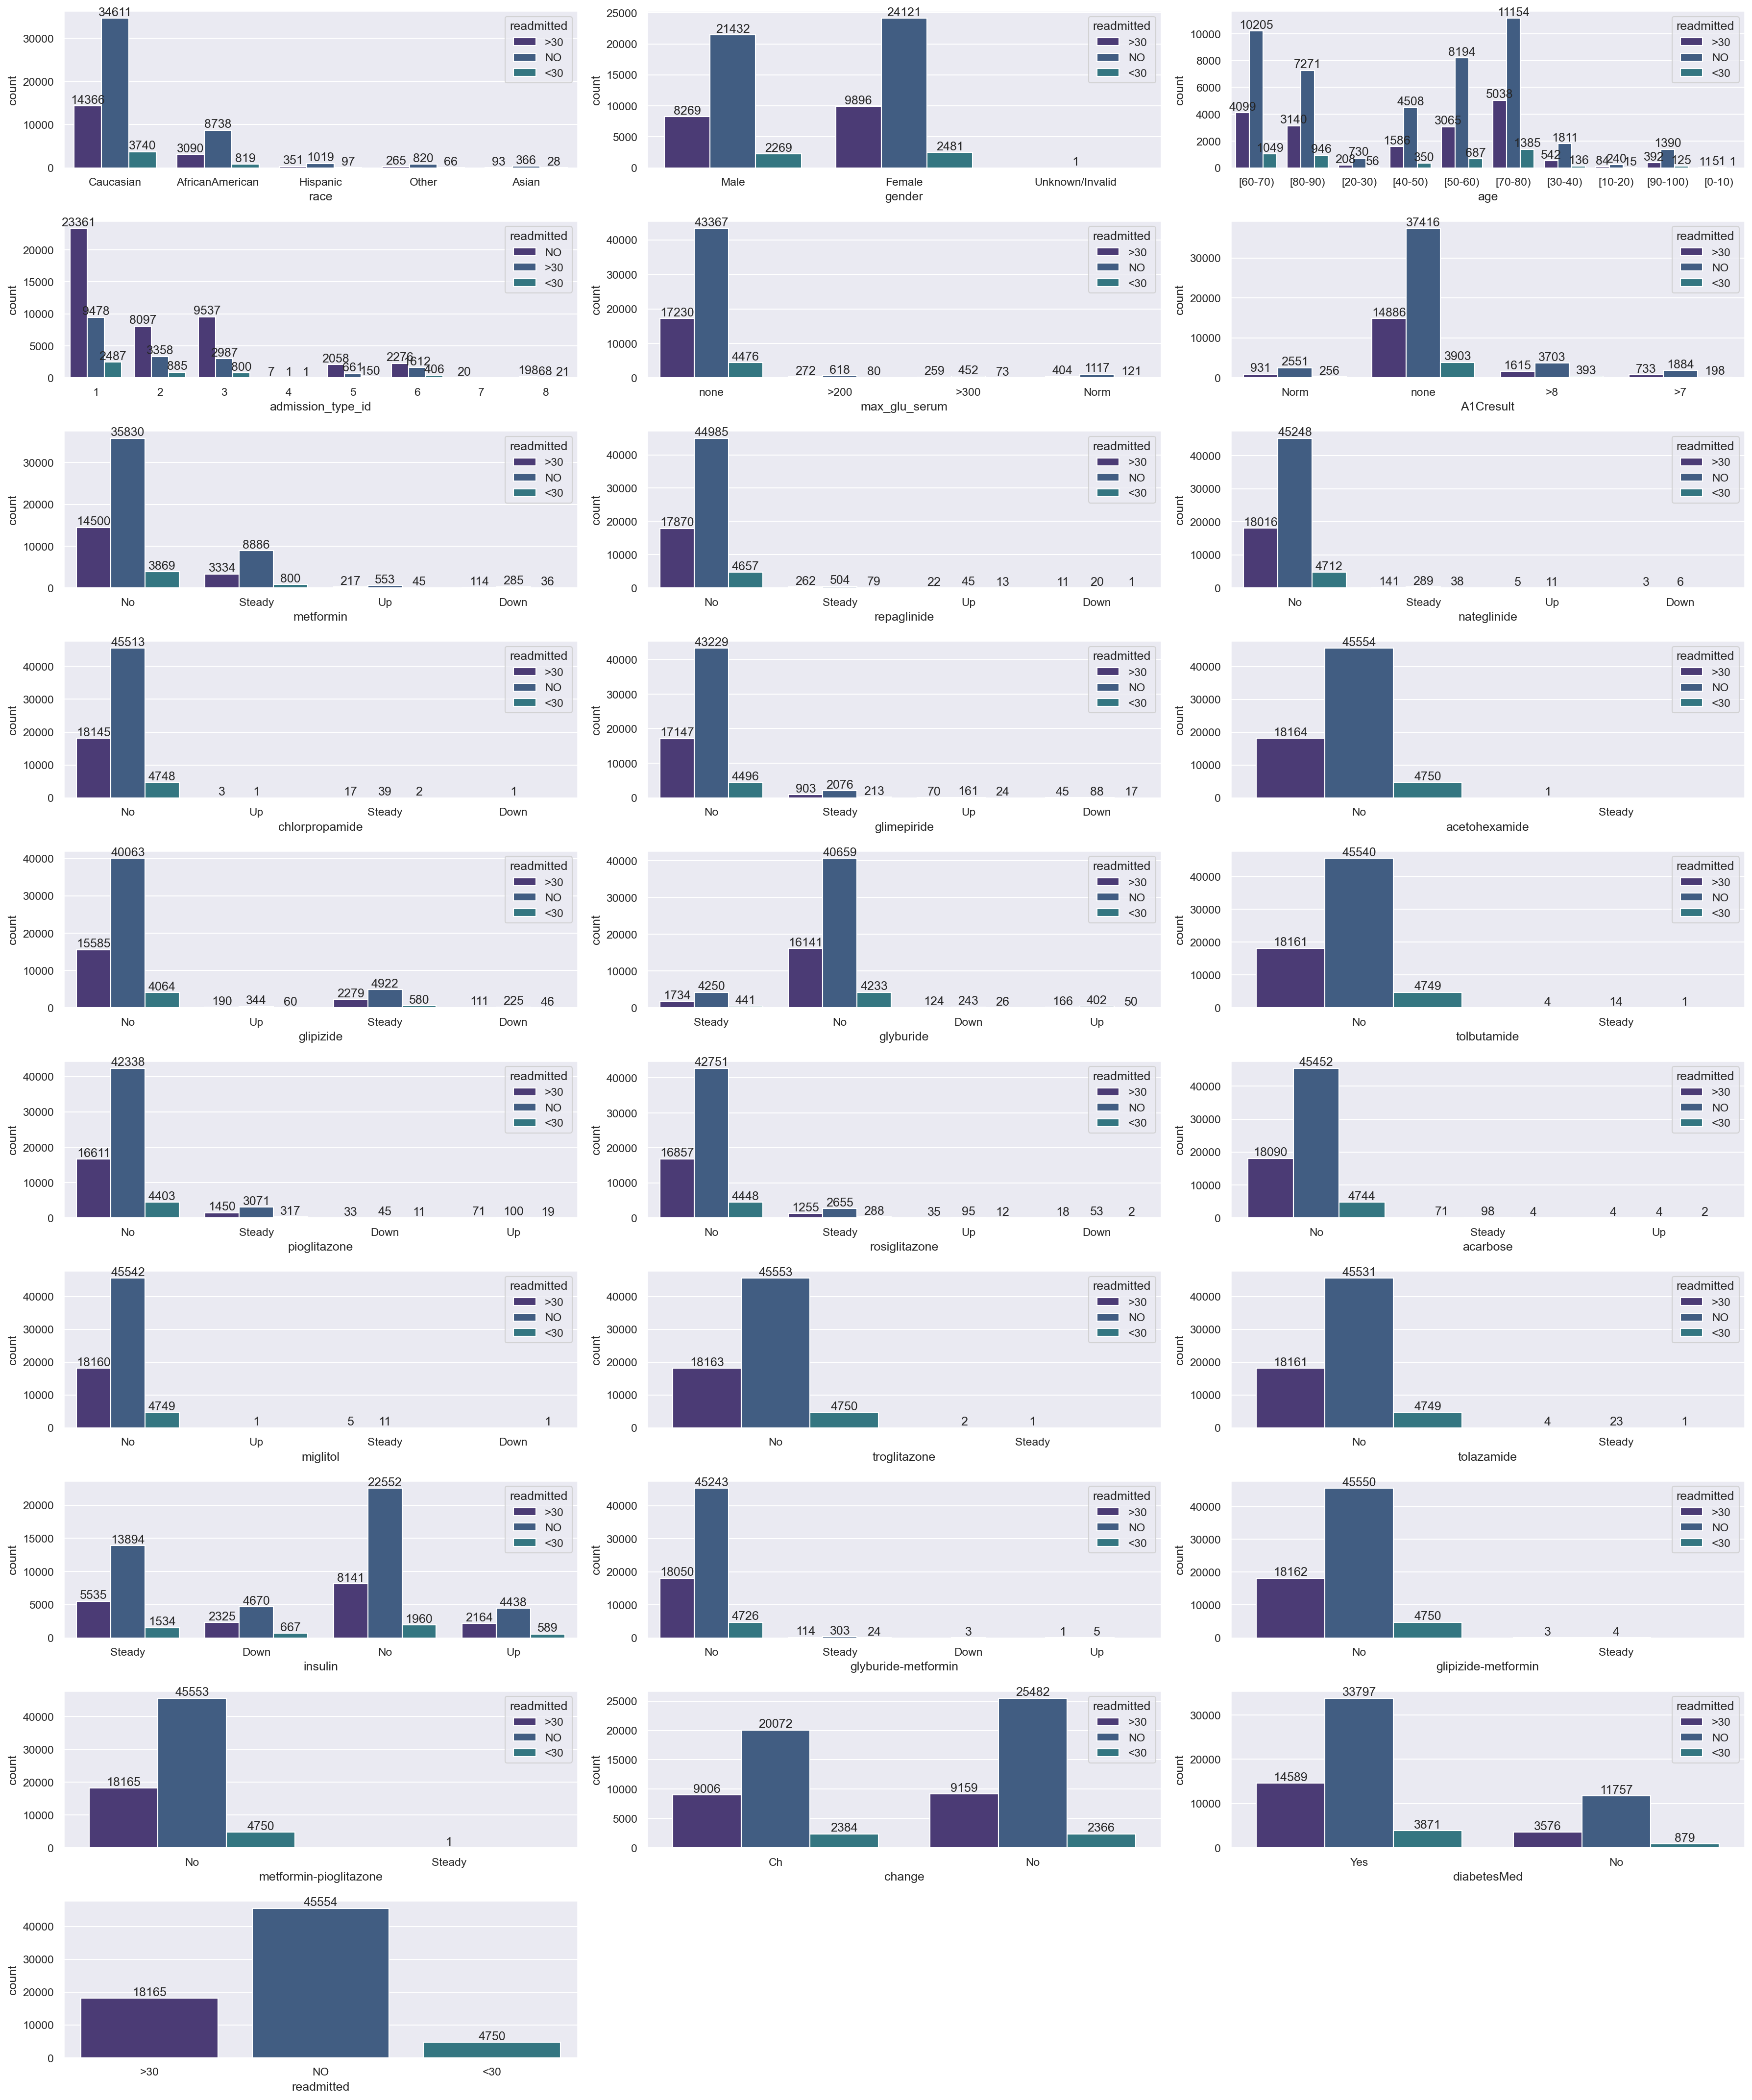

In [234]:
# Set up a 3x3 grid of subplots for boxplots
fig, axes = plt.subplots(12, 3, figsize=(24, 34))
axes = axes.flatten()

# Plot a boxplot for each numerical feature grouped by 'readmitted'
for i, feature in enumerate(low_card_categorical_cols+["readmitted"]):
    ax = axes[i]
    sns.countplot(data=low_card_categorical_features_only_df, x=feature, hue="readmitted", ax=ax)
    # Add count labels to each bar
    for container in ax.containers:
        ax.bar_label(container)


# Remove any unused subplots if less than 9 features
for j in range(len(low_card_categorical_cols)+1, 36):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

The count plots of the categorical features segmented by target class reveal a disadvantageous fact about the features in this dataset: namely, most of the features carry very little predictive power individually. This can be seen in how most categories across features are distributed almost identically to the target, `readmitted`. More concretely, the target is similarly distributed across most categories.

Another issue is how scarcely represented some of the categories are. A large number of the features relate to the administration of a certain drug. As can be seen above, a vast majority of entries in the dataset indicate `No`—as in, the drug wasn't administered. In the very rare case where it is administered, the distribution aligns with the target very closely. So again, little discriminative power.

Based on the above, we will drop a number of features. The features that will be retained are:

In [235]:
reduced_categorical_features = [
    'race',
    'gender',
    'age',
    'admission_type_id',
    'discharge_disposition_id',
    'admission_source_id',
    'diag_1',
    'diag_2',
    'diag_3',
    'max_glu_serum',
    'A1Cresult',
    'metformin',
    'repaglinide',
    'nateglinide',
    'glimepiride',
    'glipizide',
    'glyburide',
    'pioglitazone',
    'rosiglitazone',
    'acarbose',
    'insulin',
    'change',
    'diabetesMed']

#### Binning Diagnosis Features

The diagnosis features are very high in cardinality, which will effect model performance negatively. Following the lead of the work in https://yungchou.github.io/site/, we will bin them into 9 categories each. 

In [236]:
def map_icd9(code):
    try:
        code = str(code)
        # Handle non-numeric codes first
        if code.startswith('V') or code.startswith('E'):
            return 'External causes'

        num = float(code)

        if 390 <= num <= 459 or num == 785: return 'Circulatory'
        if 460 <= num <= 519 or num == 786: return 'Respiratory'
        if 520 <= num <= 579 or num == 787: return 'Digestive'
        if 250 <= num < 251:                return 'Diabetes'
        if 800 <= num <= 999:               return 'Injury'
        if 710 <= num <= 739:               return 'Musculoskeletal'
        if 580 <= num <= 629 or num == 788: return 'Genitourinary'
        if 140 <= num <= 239:               return 'Neoplasms'
        return 'Other'

    except (ValueError, TypeError):
        return 'Other'

for col in ['diag_1', 'diag_2', 'diag_3']:
    missingness_fixed_diabetes_df[col] = missingness_fixed_diabetes_df[col].apply(map_icd9)

In [237]:
reduced_categorical_features_only_df = missingness_fixed_diabetes_df[reduced_categorical_features]
reduced_categorical_features_only_df['readmitted'] = missingness_fixed_diabetes_df['readmitted']
reduced_categorical_features_only_df.head()

,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,diag_1,diag_2,diag_3,max_glu_serum,...,glimepiride,glipizide,glyburide,pioglitazone,rosiglitazone,acarbose,insulin,change,diabetesMed,readmitted
28819,Caucasian,Male,[60-70),2,1,1,Diabetes,Other,Other,none,...,No,No,Steady,No,No,No,Steady,Ch,Yes,>30
19368,Caucasian,Female,[80-90),1,3,7,Circulatory,Diabetes,Genitourinary,none,...,No,No,No,No,Steady,No,Down,Ch,Yes,NO
74178,AfricanAmerican,Male,[80-90),2,6,1,External causes,Circulatory,Circulatory,none,...,No,No,No,No,No,No,No,No,No,NO
38988,Caucasian,Female,[20-30),1,3,5,Diabetes,Other,External causes,none,...,No,No,No,No,No,No,Down,Ch,Yes,NO
24998,Caucasian,Male,[80-90),6,22,17,Circulatory,Respiratory,Genitourinary,none,...,No,No,No,No,No,No,Down,Ch,Yes,>30


#### Cramier's V

In [238]:
# feature_names = diabetes_df[categorical_cols].columns.to_list()
cr_v_scores = []
for feature in reduced_categorical_features:
    cr_v_scores.append(cramers_v(diabetes_df[feature], diabetes_df['readmitted']))

cr_v_scores = pd.DataFrame(data=cr_v_scores, index = reduced_categorical_features,
columns = ["Cramier's V"]).sort_values(by="Cramier's V")
cr_v_scores

,Cramier's V
glyburide,0.006825
nateglinide,0.006904
A1Cresult,0.007603
glimepiride,0.009675
gender,0.011139
acarbose,0.013339
metformin,0.014485
rosiglitazone,0.014612
repaglinide,0.015329
max_glu_serum,0.015934


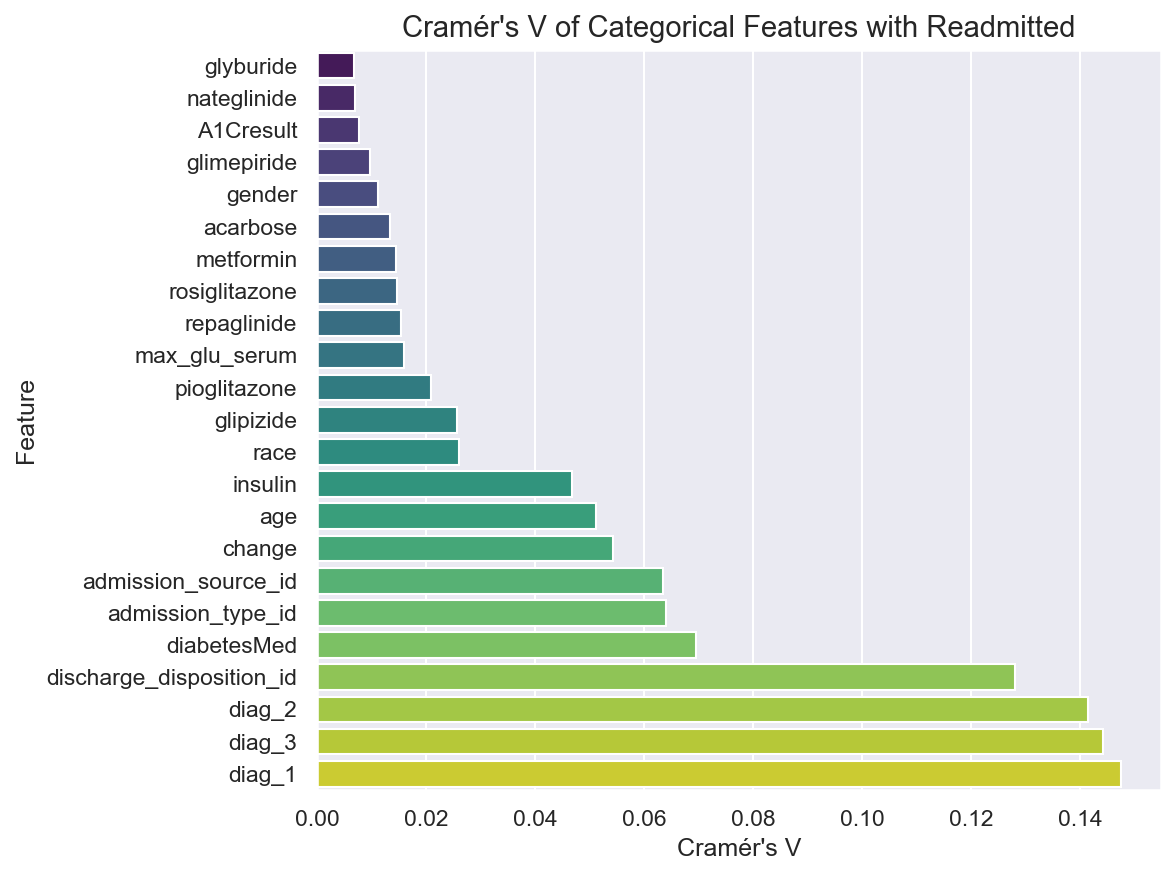

In [239]:
plt.figure(figsize=(8, 6))
sns.barplot(
    data=cr_v_scores,
    x="Cramier's V",
    y=cr_v_scores.index,
    hue= cr_v_scores.index,
    palette="viridis"
)
plt.xlabel("Cramér's V")
plt.ylabel("Feature")
plt.title("Cramér's V of Categorical Features with Readmitted")
plt.tight_layout()
plt.show()

In [240]:
final_categorical_features = [
    'race',
    'gender',
    'admission_type_id',
    'discharge_disposition_id',
    'admission_source_id',
    'diag_1',
    'diag_2',
    'diag_3',
    'max_glu_serum',
    'A1Cresult',
    'metformin',
    'repaglinide',
    'nateglinide',
    'glimepiride',
    'glipizide',
    'glyburide',
    'pioglitazone',
    'rosiglitazone',
    'acarbose',
    'insulin',
    'change',
    'diabetesMed']

final_ordinal_features = ['age']

final_numerical_features = numerical_cols

# Summary of final feature selection
print("Final features selected for modeling:")
print(f"Categorical: {len(final_categorical_features)}")
print(f"Ordinal: {len(final_ordinal_features)}")
print(f"Numerical: {len(final_numerical_features)}")

Final features selected for modeling:
Categorical: 22
Ordinal: 1
Numerical: 8


### IMBALANCE

In [241]:
# Calculate the percentage distribution for each class in the 'readmitted' column
s = np.round(100 * diabetes_df['readmitted'].value_counts() / len(diabetes_df), 2)
pd.DataFrame(data=s.values, index=s.index, columns=['Class percentage (%)'])

,Class percentage (%)
readmitted,
NO,67.01
>30,26.16
<30,6.83


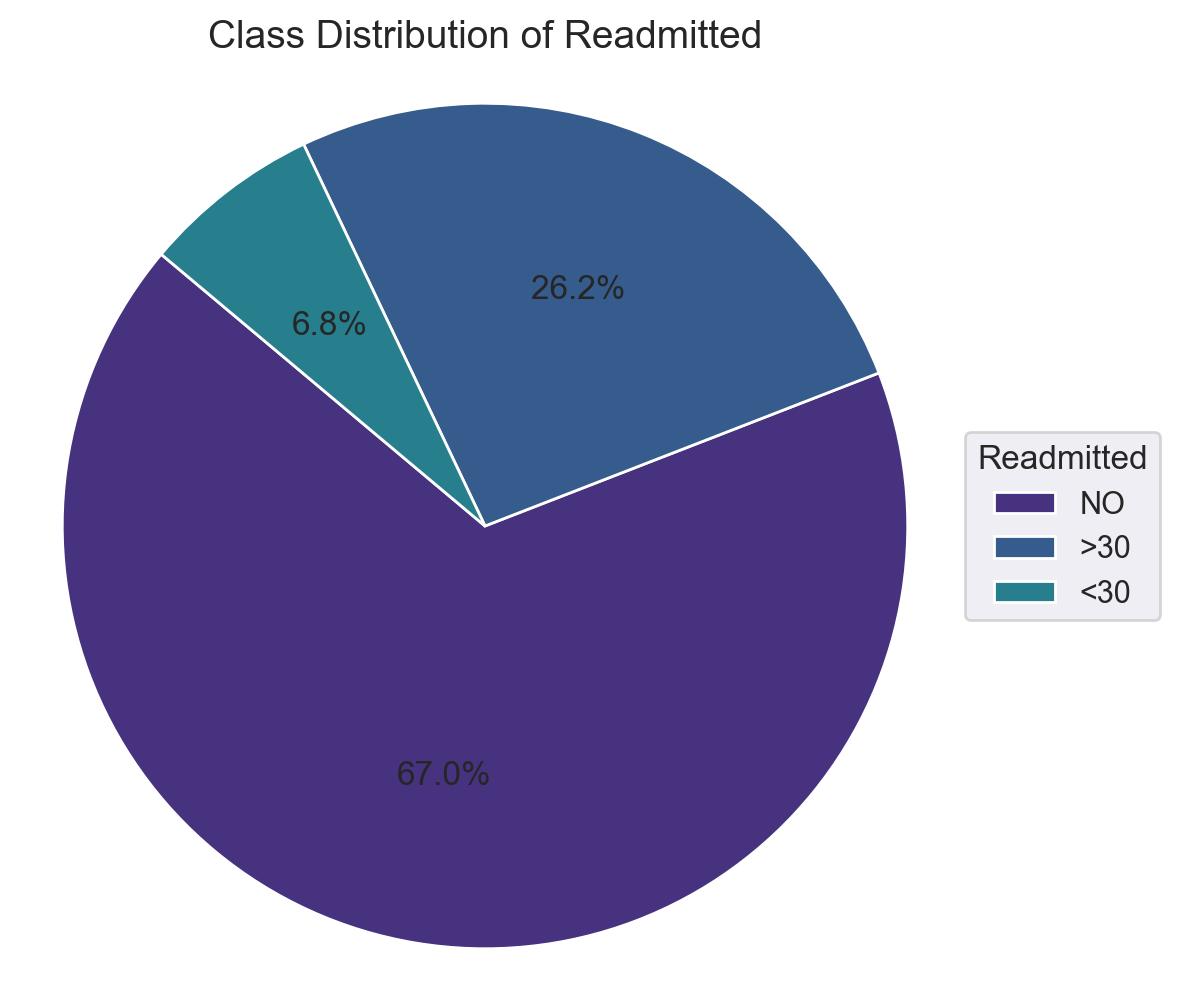

In [242]:
# Create a pie chart of the class distribution
plt.figure(figsize=(6,6), dpi=200)
wedges, texts, autotexts = plt.pie(s, autopct='%1.1f%%', startangle=140)
plt.title('Class Distribution of Readmitted')
plt.axis('equal')
plt.legend(wedges, s.index, title="Readmitted", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))
plt.show()

## Modeling

### Data Split

In [243]:
df = missingness_fixed_diabetes_df[final_categorical_features+final_numerical_features+final_ordinal_features]
df["readmitted"]=diabetes_df[~nan_rows]["readmitted"]
X = df.drop("readmitted", axis = 1)
y = df["readmitted"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)


In [244]:
# Refined categorical and numerical col selection
low_card_categorical_cols = [category for category in final_categorical_features if df[category].nunique()<=10]
high_card_categorical_cols = [category for category in final_categorical_features if df[category].nunique()>10]
ordinal_categorical_cols = ['age']

### Pipeline Setup

In [305]:
# Setup pipelines
low_card_categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
low_card_categorical_transformer.set_output(transform="pandas")

high_card_categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', TargetEncoder(smooth='auto', cv=5, random_state=42))
])
high_card_categorical_transformer.set_output(transform="pandas")

ordinal_categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])
ordinal_categorical_transformer.set_output(transform="pandas")

numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])
numerical_transformer.set_output(transform="pandas")

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('low_card_cat', low_card_categorical_transformer, low_card_categorical_cols),
        ('high_card_cat', high_card_categorical_transformer, high_card_categorical_cols),
        ('ordinal_cat', ordinal_categorical_transformer, ordinal_categorical_cols)
    ],
    remainder='passthrough',
    verbose_feature_names_out=False
)
preprocessor.set_output(transform="pandas")


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('low_card_cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``f

### Model Selection

In [246]:
model_performance = {}
model_performance['f1_macro'] = {}

#### Decision Tree

##### Stratified 5-Fold Training

In [306]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(max_depth=10, class_weight='balanced', random_state=42))
])

# Cross-validate the entire pipeline
pipeline_predict_scores = cross_val_predict(
    pipeline, X_train, y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    method='predict'
)

##### Performance Analysis

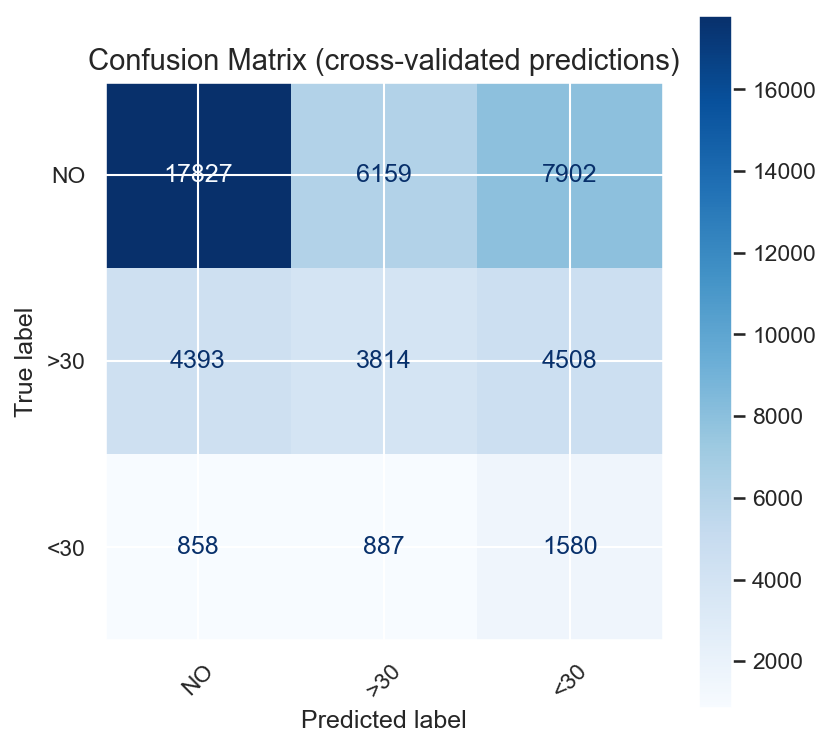

Cross-validated Accuracy: 0.4845

Classification Report:
              precision    recall  f1-score   support

          NO       0.77      0.56      0.65     31888
         >30       0.35      0.30      0.32     12715
         <30       0.11      0.48      0.18      3325

    accuracy                           0.48     47928
   macro avg       0.41      0.44      0.38     47928
weighted avg       0.61      0.48      0.53     47928



In [248]:
labels = ['NO', '>30', '<30']

# Map numeric predictions back to original (if using LabelEncoder earlier, decode here if needed)
# For now, assume y_train is already numeric/categorical as expected by confusion_matrix

cm = confusion_matrix(y_train, pipeline_predict_scores, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
fig, ax = plt.subplots(figsize=(6,6))
disp.plot(ax=ax, cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix (cross-validated predictions)")
plt.show()

# Summarize the model performance with accuracy, precision, recall, and f1-score
# Accuracy
accuracy = accuracy_score(y_train, pipeline_predict_scores)
print(f'Cross-validated Accuracy: {accuracy:.4f}\n')

# Classification report (precision, recall, f1-score per class)
print('Classification Report:')
print(classification_report(y_train, pipeline_predict_scores, labels=labels))

model_performance['f1_macro']['Decision Tree'] = float(classification_report(y_train, pipeline_predict_scores, labels=labels).split()[-8])

#### Logistic Regression

##### Stratified 5-Fold Training

In [249]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])

# Cross-validate the entire pipeline
pipeline_predict_scores = cross_val_predict(
    pipeline, X_train, y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    method='predict'
)

##### Performance Analysis

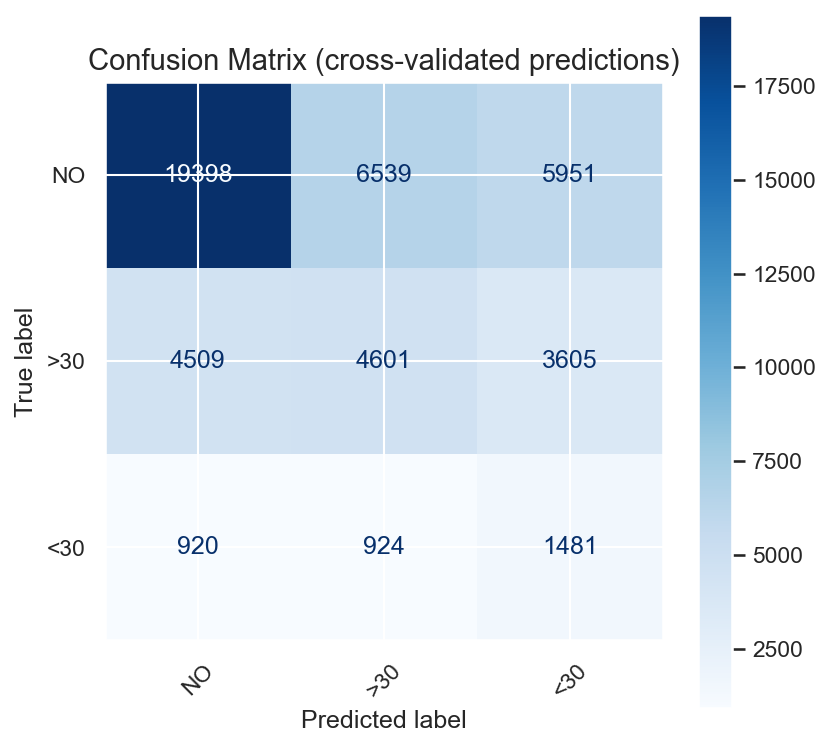

Cross-validated Accuracy: 0.5316

Classification Report:
              precision    recall  f1-score   support

          NO       0.78      0.61      0.68     31888
         >30       0.38      0.36      0.37     12715
         <30       0.13      0.45      0.21      3325

    accuracy                           0.53     47928
   macro avg       0.43      0.47      0.42     47928
weighted avg       0.63      0.53      0.57     47928



In [250]:
cm = confusion_matrix(y_train, pipeline_predict_scores, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
fig, ax = plt.subplots(figsize=(6,6))
disp.plot(ax=ax, cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix (cross-validated predictions)")
plt.show()

# Summarize the model performance with accuracy, precision, recall, and f1-score
# Accuracy
accuracy = accuracy_score(y_train, pipeline_predict_scores)
print(f'Cross-validated Accuracy: {accuracy:.4f}\n')

# Classification report (precision, recall, f1-score per class)
print('Classification Report:')
print(classification_report(y_train, pipeline_predict_scores, labels=labels))

model_performance['f1_macro']['Logistic Regression'] = float(classification_report(y_train, pipeline_predict_scores, labels=labels).split()[-8])

#### Random Forest

##### Stratified 5-Fold Training 

In [251]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42))
])

# Cross-validate the entire pipeline
pipeline_predict_scores = cross_val_predict(
    pipeline, X_train, y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    method='predict'
)

##### Performance Analysis

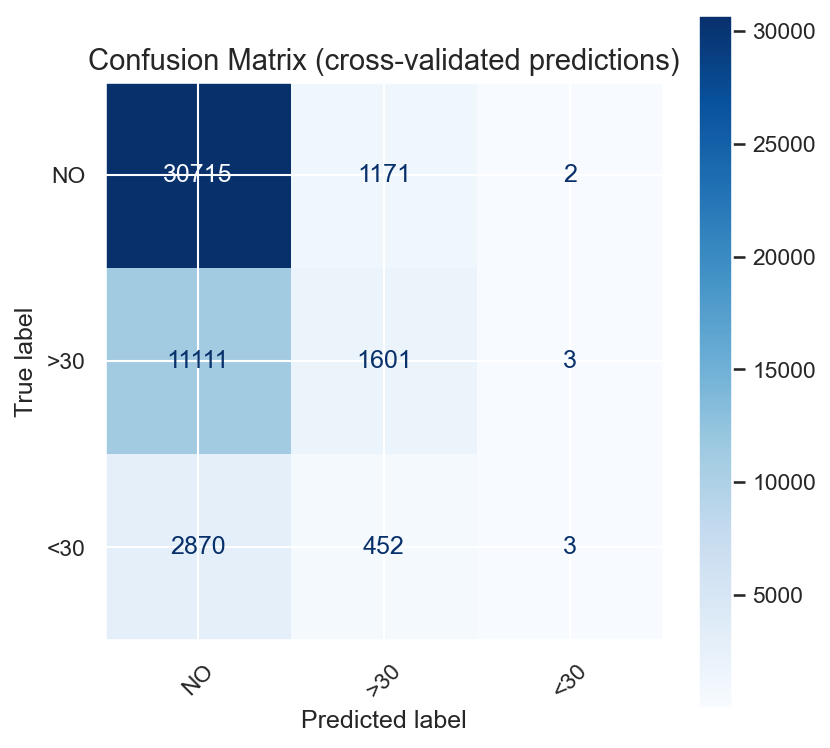

Cross-validated Accuracy: 0.6743

Classification Report:
              precision    recall  f1-score   support

          NO       0.69      0.96      0.80     31888
         >30       0.50      0.13      0.20     12715
         <30       0.38      0.00      0.00      3325

    accuracy                           0.67     47928
   macro avg       0.52      0.36      0.33     47928
weighted avg       0.61      0.67      0.59     47928



In [252]:
cm = confusion_matrix(y_train, pipeline_predict_scores, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
fig, ax = plt.subplots(figsize=(6,6))
disp.plot(ax=ax, cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix (cross-validated predictions)")
plt.show()

# Summarize the model performance with accuracy, precision, recall, and f1-score
# Accuracy
accuracy = accuracy_score(y_train, pipeline_predict_scores)
print(f'Cross-validated Accuracy: {accuracy:.4f}\n')

# Classification report (precision, recall, f1-score per class)
print('Classification Report:')
print(classification_report(y_train, pipeline_predict_scores, labels=labels))

model_performance['f1_macro']['Random Forest'] = float(classification_report(y_train, pipeline_predict_scores, labels=labels).split()[-8])

#### Gradient Boosting

##### Stratified 5-Fold Training

In [253]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(random_state=42))
])

# Cross-validate the entire pipeline
pipeline_predict_scores = cross_val_predict(
    pipeline, X_train, y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    method='predict'
)

##### Performance Analysis

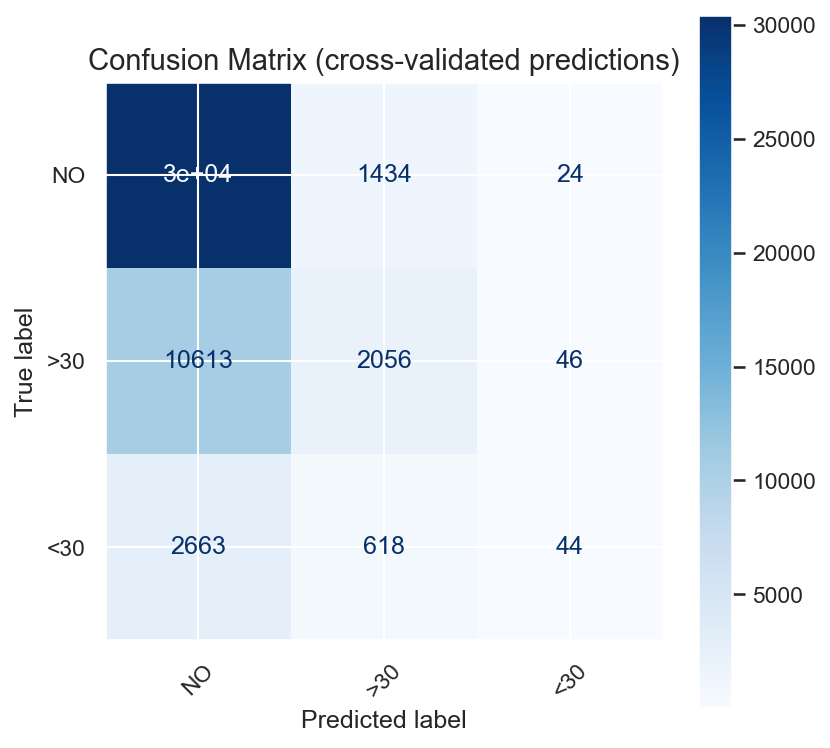

Cross-validated Accuracy: 0.6787

Classification Report:
              precision    recall  f1-score   support

          NO       0.70      0.95      0.81     31888
         >30       0.50      0.16      0.24     12715
         <30       0.39      0.01      0.03      3325

    accuracy                           0.68     47928
   macro avg       0.53      0.38      0.36     47928
weighted avg       0.62      0.68      0.60     47928



In [254]:
cm = confusion_matrix(y_train, pipeline_predict_scores, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
fig, ax = plt.subplots(figsize=(6,6))
disp.plot(ax=ax, cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix (cross-validated predictions)")
plt.show()

# Summarize the model performance with accuracy, precision, recall, and f1-score
# Accuracy
accuracy = accuracy_score(y_train, pipeline_predict_scores)
print(f'Cross-validated Accuracy: {accuracy:.4f}\n')

# Classification report (precision, recall, f1-score per class)
print('Classification Report:')
print(classification_report(y_train, pipeline_predict_scores, labels=labels))

model_performance['f1_macro']['Gradient Boosting'] = float(classification_report(y_train, pipeline_predict_scores, labels=labels).split()[-8])

#### XGBoost

##### Target Encoding

In [292]:
# Label encode the target variable for multiclass classification
le = LabelEncoder()

# Encode the y_train split using the same fitted encoder
y_train_encoded = le.fit_transform(y_train.tolist())

##### Stratified 5-Fold Training

In [256]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(objective='multi:softmax', num_class=3, random_state=42))
])

# Cross-validate the entire pipeline
pipeline_predict_scores = cross_val_predict(
    pipeline, X_train, y_train_encoded,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    method='predict'
)

##### Performance Analysis

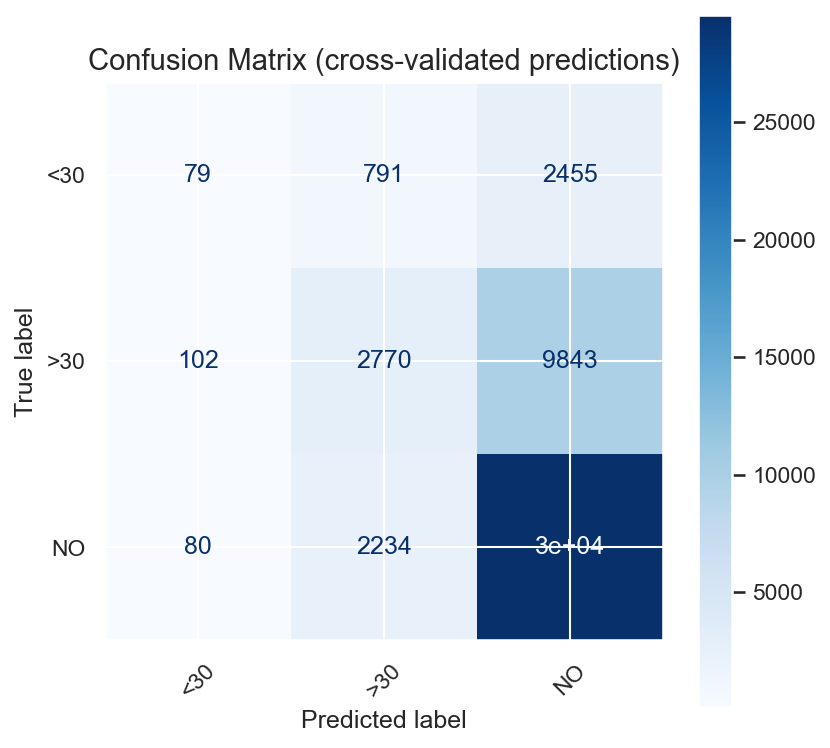

Cross-validated Accuracy: 0.6765

Classification Report:
              precision    recall  f1-score   support

         <30       0.30      0.02      0.04      3325
         >30       0.48      0.22      0.30     12715
          NO       0.71      0.93      0.80     31888

    accuracy                           0.68     47928
   macro avg       0.50      0.39      0.38     47928
weighted avg       0.62      0.68      0.62     47928



In [257]:
cm = confusion_matrix(y_train_encoded, pipeline_predict_scores)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_.tolist())
fig, ax = plt.subplots(figsize=(6,6))
disp.plot(ax=ax, cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix (cross-validated predictions)")
plt.show()

# Summarize the model performance with accuracy, precision, recall, and f1-score
# Accuracy
accuracy = accuracy_score(y_train_encoded, pipeline_predict_scores)
print(f'Cross-validated Accuracy: {accuracy:.4f}\n')

# Classification report (precision, recall, f1-score per class)
print('Classification Report:')
print(classification_report(y_train_encoded, pipeline_predict_scores, target_names=le.classes_.tolist()))

model_performance['f1_macro']['XGBoost'] = float(classification_report(y_train_encoded, pipeline_predict_scores, target_names=le.classes_.tolist()).split()[-8])

#### LightGBM

##### Stratified 5-Fold Training

In [258]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LGBMClassifier(class_weight='balanced', random_state=42, verbose=-1))
])

# Cross-validate the entire pipeline
pipeline_predict_scores = cross_val_predict(
    pipeline, X_train, y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    method='predict'
)

/Users/hajj/Programming/Python/Projects/Hospital Readmission Risk Analysis for Diabetic Patients/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/hajj/Programming/Python/Projects/Hospital Readmission Risk Analysis for Diabetic Patients/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/hajj/Programming/Python/Projects/Hospital Readmission Risk Analysis for Diabetic Patients/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/hajj/Programming/Python/Projects/Hospital Readmission Risk Analysis for Diabetic Patients/.venv/lib/python3.12/site-packages/sklearn/utils/validati

##### Performance Analysis

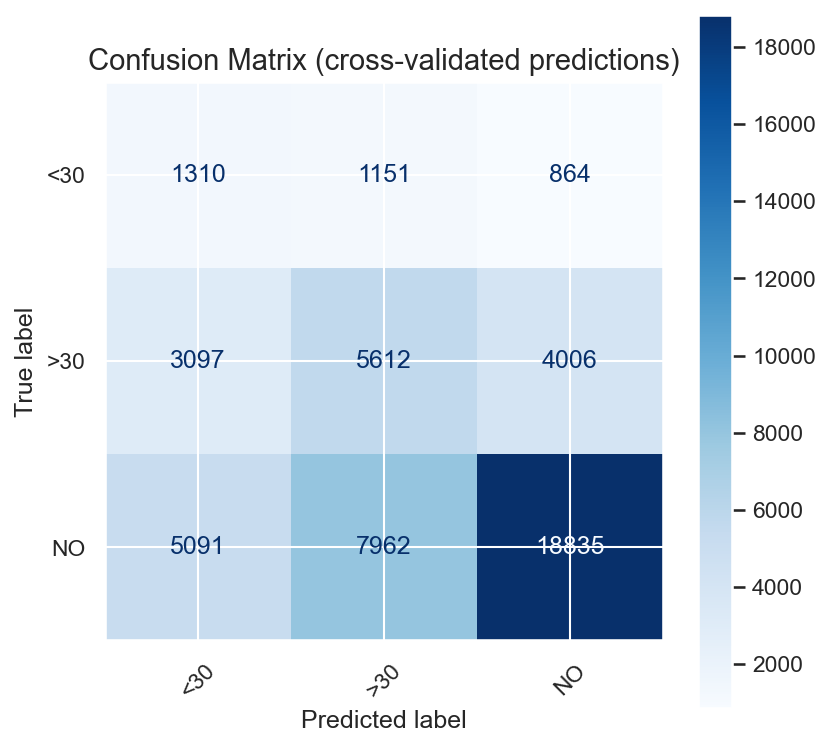

Cross-validated Accuracy: 0.5374

Classification Report:
              precision    recall  f1-score   support

         <30       0.14      0.39      0.20      3325
         >30       0.38      0.44      0.41     12715
          NO       0.79      0.59      0.68     31888

    accuracy                           0.54     47928
   macro avg       0.44      0.48      0.43     47928
weighted avg       0.64      0.54      0.57     47928



In [259]:
cm = confusion_matrix(y_train, pipeline_predict_scores)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_.tolist())
fig, ax = plt.subplots(figsize=(6,6))
disp.plot(ax=ax, cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix (cross-validated predictions)")
plt.show()

# Summarize the model performance with accuracy, precision, recall, and f1-score
# Accuracy
accuracy = accuracy_score(y_train, pipeline_predict_scores)
print(f'Cross-validated Accuracy: {accuracy:.4f}\n')

# Classification report (precision, recall, f1-score per class)
print('Classification Report:')
print(classification_report(y_train, pipeline_predict_scores, target_names=le.classes_.tolist()))

model_performance['f1_macro']['LightGBM'] = float(classification_report(y_train, pipeline_predict_scores, target_names=le.classes_.tolist()).split()[-8])

#### Best Tested Model 

In this project, we tracked the performance of each tested model by evaluating their cross-validated scores—specifically, using metrics such as accuracy, precision, recall, and f1-score per class. For comparison across different models, we stored the macro-averaged F1 score (f1_macro) of each model’s predictions in a central results table (model_performance), allowing us to sort and identify the best models.

We selected f1_macro as the primary metric because our target variable (readmission status) is imbalanced: some classes are much less frequent than others. The macro F1 score calculates the F1 score independently for each class and then takes the average, treating all classes equally, regardless of their support (frequency). This helps ensure that model performance on minority classes is not ignored, and that a model performing well on all classes (not just the majority) is rewarded. This makes f1_macro especially suitable for evaluating models in imbalanced multi-class classification tasks like ours.

In [266]:
# Display sorted model performance by f1_macro score
pd.DataFrame(model_performance).sort_values(by='f1_macro', ascending=False)

,f1_macro
LightGBM,0.43
Logistic Regression,0.42
Decision Tree,0.38
XGBoost,0.38
Gradient Boosting,0.36
Random Forest,0.33


In [ ]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LGBMClassifier(class_weight='balanced', random_state=42, verbose=-1))
])

param_grid = {
    'classifier__n_estimators': [150, 200, 250],
    'classifier__max_depth': [4, 6, 8],
    'classifier__learning_rate': [0.05, 0.1],
    'classifier__num_leaves': [31, 63],
    'classifier__min_child_samples': [20, 50],
    'classifier__class_weight': ['balanced']
}

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1_macro',
    refit=True,
    n_jobs=-1
)
grid_search.fit(X_train, y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...verbose=-1))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__class_weight': ['balanced'], 'classifier__learning_rate': [0.05, 0.1], 'classifier__max_depth': [4, 6, ...], 'classifier__min_child_samples': [20, 50], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the

In [308]:
best_pipeline = grid_search.best_estimator_
print("Best estimator parameters:")
print(grid_search.best_params_)

Best estimator parameters:
{'classifier__class_weight': 'balanced', 'classifier__learning_rate': 0.1, 'classifier__max_depth': 8, 'classifier__min_child_samples': 50, 'classifier__n_estimators': 250, 'classifier__num_leaves': 63}


In [309]:
scores = cross_val_score(
    best_pipeline, X_train, y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1_macro'
)
mean_score = scores.mean()
std_score = scores.std()
print(f"The mean cross-validated F1 macro score is: {mean_score:.4f}")
print(f"The standard deviation of the cross-validated F1 macro score is: {std_score:.4f}")

The mean cross-validated F1 macro score is: 0.4403
The standard deviation of the cross-validated F1 macro score is: 0.0067


#### Testing on Final Model

In [ ]:
from sklearn.metrics import f1_score
# Test the final model (best_pipeline) on the holdout set X_test
y_test_pred = best_pipeline.predict(X_test)
print("Classification Report on Holdout Set:")
print(classification_report(y_test, y_test_pred, target_names=le.classes_.tolist()))


Classification Report on Holdout Set:
              precision    recall  f1-score   support

         <30       0.15      0.29      0.20      1425
         >30       0.37      0.46      0.41      5450
          NO       0.78      0.63      0.69     13666

    accuracy                           0.56     20541
   macro avg       0.43      0.46      0.44     20541
weighted avg       0.63      0.56      0.59     20541

